In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("clientes_ventas_sucio.csv", encoding='utf-8-sig')

print(f"filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

filas: 5,210 | Columnas: 17


In [4]:
df.head()

,cliente_id,nombre,email,telefono,edad,genero,ciudad,categoria_producto,monto_compra,salario_mensual,score_satisfaccion,metodo_pago,fecha_registro,fecha_ultima_compra,estado_cliente,num_compras,region
0,1.0,Sergio Gómez,usuario1@empresa.co,NaN,22,F,CALI,Tecnología,47123.36,3348625.06,9.5,Tarjeta Débito,2020-03-04,06-01-2023,Pendiente,16.0,Oriente
1,2.0,Carlos González,usuario2@hotmail.com,NaN,35,Femenino,Cartagena,Ropa,41641.38,2807157.91,6.6,PSE,17/01/2022,28/06/2020,Cancelado,23.0,NaN
2,3.0,Juan Gómez,usuario3gmail.com,3012512204,31,Femenino,Cali,ROPA,133145.84,3586614.16,7.9,Tarjeta Crédito,01-11-2020,30-06-2024,Inactivo,34.0,Sur
3,4.0,Paola López,usuario4@outlook.com,3153714180,64,M,Bucaramanga,Electrónica,357533.52,2657708.20,NaN,Nequi,2022-03-10,19-01-2023,Pendiente,29.0,Sur
4,5.0,Sandra González,NaN,3158003954,54,Male,Bogotá,Alimentos,5327.67,3991891.30,2.2,Efectivo,22/05/2023,09-19-2022,Inactivo,33.0,Sur


In [5]:
df.tail(15)

,cliente_id,nombre,email,telefono,edad,genero,ciudad,categoria_producto,monto_compra,salario_mensual,score_satisfaccion,metodo_pago,fecha_registro,fecha_ultima_compra,estado_cliente,num_compras,region
5195,582.0,Natalia Ramírez,sin_email,3115120387,25,F,Pereira,ROPA,86398.07,3773460.27,8.0,TARJETA CREDITO,13-08-2024,03 Feb 2024,Pendiente,8.0,Oriente
5196,483.0,Juan Sánchez,usuario483@yahoo.com,3107331506,52,Female,Barranquilla,Tecnología,650713.78,1922937.33,NaN,PSE,04 Apr 2022,11 Dec 2020,Activo,44.0,Occidente
5197,1876.0,Juan Gómez,usuario1876@empresa.co,3008008179,31,Male,Barranquilla,deportes,77467.79,2568219.88,2.3,pse,2023-03-11,05-05-2024,Pendiente,3.0,Norte
5198,553.0,Pedro González,usuario553@outlook.com,3008608139,60,F,Santa Marta,Ropa,11658.58,3317663.65,5.5,Efectivo,27-05-2020,28 Jan 2021,Inactivo,31.0,Centro
5199,258.0,Ana Rivera,usuario258@yahoo.com,3105891236,24,M,Pereira,alimentos,67280.80,4401925.39,9.3,Nequi,21-06-2021,17/05/2024,inactivo,7.0,Occidente
5200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.describe(include='all').round(2)

,cliente_id,nombre,email,telefono,edad,genero,ciudad,categoria_producto,monto_compra,salario_mensual,score_satisfaccion,metodo_pago,fecha_registro,fecha_ultima_compra,estado_cliente,num_compras,region
count,5200.00,4981,4943,4791,4911,4727,5200,5200,4919.00,4888.00,4779.00,4720,4825,4846,5200,4938.00,4314
unique,NaN,180,4793,4695,63,10,15,11,NaN,NaN,NaN,9,3804,3835,8,NaN,5
top,NaN,Ana Torres,sin_email,no tiene,46,Masculino,Santa Marta,Deportes,NaN,NaN,NaN,PSE,09-06-2022,09-15-2024,activo,NaN,Sur
freq,NaN,48,123,35,105,504,409,495,NaN,NaN,NaN,548,6,6,697,NaN,898
mean,2498.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,492986.01,4457929.47,5.91,NaN,NaN,NaN,NaN,25.62,NaN
std,1445.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2918923.07,10086773.04,7.33,NaN,NaN,NaN,NaN,14.43,NaN
min,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5012.71,-348511.09,-1.00,NaN,NaN,NaN,NaN,1.00,NaN
25%,1249.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79042.41,2625566.62,3.10,NaN,NaN,NaN,NaN,13.00,NaN
50%,2492.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,182833.42,3465448.60,5.40,NaN,NaN,NaN,NaN,26.00,NaN
75%,3750.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,364087.64,4308996.49,7.80,NaN,NaN,NaN,NaN,38.00,NaN


In [10]:
#Revision de valores nulos

nulos = pd.DataFrame({
    'nulos':      df.isnull().sum(),
    'porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('porcentaje', ascending=False)

nulos[nulos['nulos'] > 0]

,nulos,porcentaje
region,896,17.20
metodo_pago,490,9.40
genero,483,9.27
score_satisfaccion,431,8.27
telefono,419,8.04
fecha_registro,385,7.39
fecha_ultima_compra,364,6.99
salario_mensual,322,6.18
edad,299,5.74
monto_compra,291,5.59


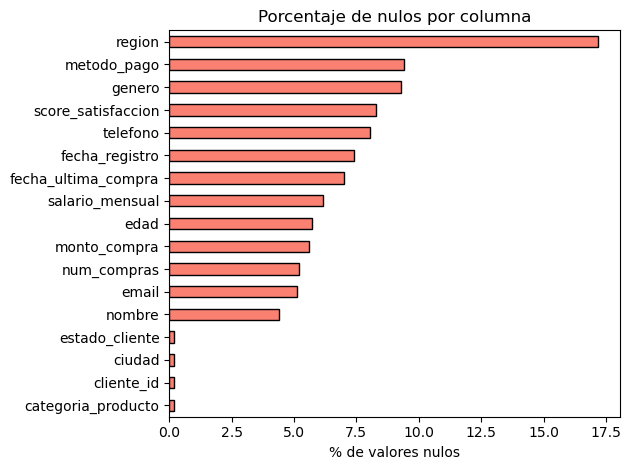

In [11]:
nulos_filtrado = nulos[nulos['nulos'] > 0]

nulos_filtrado['porcentaje'].sort_values().plot(
    kind='barh',
    color='salmon',
    edgecolor='black'
)

plt.title("Porcentaje de nulos por columna")
plt.xlabel('% de valores nulos')
plt.tight_layout()
plt.show()

In [12]:
filas_vacias = df[df.isnull().all(axis=1)]
print(f"filas completamente vacías: {len(filas_vacias)}")

filas completamente vacías: 10


In [13]:
#eliminación de filas vacías
df = df.dropna(how='all').reset_index(drop=True)
print(f'filas al elimnar vacías: {len(df):,}')

filas al elimnar vacías: 5,200


In [14]:
#Duplicados
total_dupli = df.duplicated().sum()
print(f"Filas completamente duplicadas: {total_dupli}")

Filas completamente duplicadas: 0


In [15]:
dupli_id = df[df.duplicated(subset='cliente_id', keep=False)]
print(f"filas con cliente_id duplicado: {len(dupli_id)}")

filas con cliente_id duplicado: 400


In [16]:
dupli_id.sort_values('cliente_id').head(8)

,cliente_id,nombre,email,telefono,edad,genero,ciudad,categoria_producto,monto_compra,salario_mensual,score_satisfaccion,metodo_pago,fecha_registro,fecha_ultima_compra,estado_cliente,num_compras,region
5149,5.0,Diana Martínez,usuario5@empresa.co,3122332274,68,MASCULINO,Barranquilla,ROPA,443061.61,3411873.42,6.5,pse,18 Nov 2020,05-28-2022,activo,38.0,Oriente
4,5.0,Sandra González,NaN,3158003954,54,Male,Bogotá,Alimentos,5327.67,3991891.30,2.2,Efectivo,22/05/2023,09-19-2022,Inactivo,33.0,Sur
26,27.0,Diana Rodríguez,usuario27@hotmail.com,3118704462,31,m,medellin,Hogar,266113.93,2125744.46,4.4,Efectivo,09-11-2023,01-03-2022,Pendiente,9.0,Oriente
5136,27.0,Sergio Rivera,usuario27@gmail.com,3154060146,30,MASCULINO,Medellín,electronica,38603.97,940780.72,9.4,TARJETA CREDITO,NaN,02 Jul 2021,activo,9.0,Oriente
53,54.0,Ana González,usuario54@yahoo.com,3015162905,34,MASCULINO,Santa Marta,Electrónica,153229.86,5724272.73,NaN,Tarjeta Crédito,08-01-2020,12 May 2021,Inactivo,19.0,Oriente
5027,54.0,Pedro Rodríguez,usuario54@gmail.com,3101179269,56,Masculino,Medellín,Alimentos,285461.18,4471992.30,7.6,Tarjeta Débito,10-23-2023,2024/02/20,ACTIVO,8.0,NaN
5194,59.0,Natalia Ramírez,usuario59gmail.com,3014039165,75,NaN,Bogotá,Ropa,15822.64,4141986.47,3.9,efectivo,2022-01-23,2022/07/04,Cancelado,42.0,Centro
58,59.0,María García,usuario59@yahoo.com,3156216033,54,Masculino,barranquilla,electronica,NaN,3168458.93,2.4,pse,2024/01/17,14 Jun 2024,pendiente,13.0,Centro


In [17]:
df = df.drop_duplicates(subset='cliente_id', keep='first').reset_index(drop=True)
print(f'filas al elimnar duplicados: {len(df):,}')

filas al elimnar duplicados: 5,000


In [ ]:
#Limpieza de texto de ciudades
print('Ciudades únicas (sin limpiar): ')
print(sorted(df['ciudad'].dropna().unique()))

Ciudades únicas (sin limpiar): 
['  Cartagena  ', 'BOGOTA', 'Barranquilla', 'Bogotá', 'Bucaramanga', 'CALI', 'Cali', 'Cartagena', 'Cúcuta', 'Manizales', 'Medellín', 'Pereira', 'Santa Marta', 'barranquilla', 'medellin']


In [ ]:
#Lsita de columnas de texto que nrequieren normalización

columnas_texto = ['ciudad', 'genero', 'categoria_producto', 'metodo_pago', 'estado_cliente', 'region']

for col in columnas_texto:
    df[col] = df[col].str.strip().str.title()
    

#verificamos el reusltado de ciudades
print("Ciudades únicas después de limpiar")
print(sorted(df['ciudad'].dropna().unique()))



Ciudades únicas después de limpiar
['Efectivo', 'Nequi', 'Pse', 'Tarjeta Credito', 'Tarjeta Crédito', 'Tarjeta Débito']


In [27]:
mapa_genero = {
    'M':     'Masculino',
    'F':     'Femenino',
    'Male':  'Masculino',
    'Female':'Femenino',
}

df['genero'] = df['genero'].replace(mapa_genero)


#Verficamos
df['genero'].value_counts(dropna=False)

genero
Femenino     2300
Masculino    2240
NaN           460
Name: count, dtype: int64